# EP1 — Examen Parcial · Procesamiento de Imágenes (CC53)

## Caso aplicado y fundamentos de convolución


---

### Instrucciones generales

1. Complete los campos de identificación en la celda siguiente antes de comenzar.
2. La Parte I se responde en las celdas Markdown indicadas. Una de las preguntas requiere ejecución de código; las demás son analíticas y admiten apoyo numérico opcional.
3. La Parte II es un caso integral. Usted recibe una imagen degradada y debe entregarla en condiciones óptimas para análisis posterior, **eligiendo y justificando** los métodos de transformación que va a aplicar. No existe una única solución correcta: la evaluación pondera la coherencia entre diagnóstico, justificación, implementación y evaluación cuantitativa.
4. Todas las celdas de código deben ejecutarse sin errores al hacer *Restart & Run All*.
5. No está permitido el uso de redes neuronales preentrenadas ni de funciones de alto nivel que resuelvan el caso completo en un solo paso. Sí están permitidas las técnicas vistas en clase: operaciones aritméticas, transformación lineal (estiramiento de contraste), ecualización de histograma, umbralización (simple y Otsu), filtros espaciales gaussiano, laplaciano, mediana y Sobel, y la convolución implementada manualmente o vía `scipy.signal.convolve2d`.
6. Documente cada decisión en celdas Markdown. La calidad de la justificación pesa más que la calidad final de la imagen restaurada.


---

## Configuración inicial

La siguiente celda importa las librerías permitidas y fija la semilla. **No la modifique.**

In [1]:
# Configuración del examen - NO MODIFICAR
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy import ndimage

# Semilla fija para reproducibilidad - NO MODIFICAR
np.random.seed(2026)

plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.dpi'] = 90
print("Entorno listo.")


Entorno listo.


---

# Parte I — Fundamentos de convolución (6 puntos)

Responda en las celdas Markdown indicadas. Use notación LaTeX entre `$ ... $` o `$$ ... $$` cuando sea pertinente.


## Pregunta 1 — Cálculo manual de convolución (2 puntos)

Considere la imagen $\mathbf{F}$ y el kernel $\mathbf{H}$ siguientes:

$$
\mathbf{F} = \begin{bmatrix} 2 & 0 & 3 & 1 \\ 1 & 4 & 2 & 0 \\ 0 & 1 & 3 & 2 \\ 2 & 2 & 1 & 1 \end{bmatrix}
\qquad
\mathbf{H} = \dfrac{1}{4}\begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}
$$

Calcule **a mano** la convolución $\mathbf{G} = \mathbf{F} * \mathbf{H}$ usando:

- Padding cero alrededor de $\mathbf{F}$ (una fila/columna de ceros en cada borde).
- La definición de convolución (no correlación cruzada): recuerde voltear el kernel antes de deslizarlo.
- Modo `full` con salida del mismo tamaño que $\mathbf{F}$ tras centrado (es decir, mantenga la matriz resultante de $4\times 4$, alineando $\mathbf{H}$ de modo que su esquina superior izquierda quede en cada píxel de salida).

Muestre al menos **dos posiciones intermedias** del cálculo (la operación píxel por píxel para dos celdas distintas) antes de presentar la matriz $\mathbf{G}$ completa.


### Respuesta — Pregunta 1

**Posición (i, j) = (0, 0):**  
$$ G[0, 0] = \frac{1}{4}(F[0,0] + F[0,1] + F[1,0] + F[1,1]) = \frac{1}{4}(2 + 0 + 1 + 4) = 1.75 $$

**Posición (i, j) = (0, 1):**  
$$ G[0, 1] = \frac{1}{4}(F[0,1] + F[0,2] + F[1,1] + F[1,2]) = \frac{1}{4}(0 + 3 + 4 + 2) = 2.25 $$

**Matriz resultante $\mathbf{G}$:**

Para los bordes, usamos el padding de ceros (ventana de 2x2 saliéndose de la matriz original):

$$
\mathbf{G} = \begin{bmatrix} 1.75 & 2.25 & 1.5 & 0.25 \\ 1.5 & 2.5 & 1.75 & 0.5 \\ 1.25 & 1.75 & 1.75 & 0.75 \\ 1.0 & 0.75 & 0.5 & 0.25 \end{bmatrix}
$$

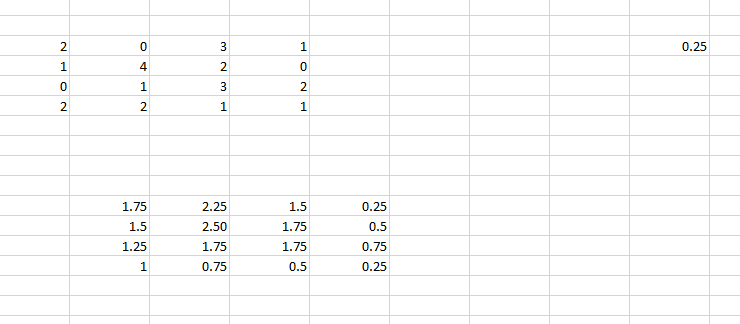

## Pregunta 2 — Verificación numérica (2 punto)

Use `scipy.signal.convolve2d` para verificar su resultado del ejercicio anterior. La celda de código a continuación define $\mathbf{F}$ y $\mathbf{H}$.

**Su tarea:**
1. Complete la llamada a `convolve2d` con los argumentos correctos (`mode` y `boundary`) para que el resultado coincida con lo calculado manualmente.
2. Imprima la matriz resultante.
3. En la celda Markdown siguiente, indique si coincide con su cálculo manual; si no, identifique el error.


In [18]:
# Verificación numérica
F = np.array([
    [2, 0, 3, 1],
    [1, 4, 2, 0],
    [0, 1, 3, 2],
    [2, 2, 1, 1]
], dtype=np.float64)

H = (1/4) * np.ones((2, 2), dtype=np.float64)

G_full = convolve2d(F, H, mode='full', boundary='fill', fillvalue=0)
G_num = G_full[1:, 1:]

print("Matriz G verificada:")
print(np.round(G_num, 4))

Matriz G verificada:
[[1.75 2.25 1.5  0.25]
 [1.5  2.5  1.75 0.5 ]
 [1.25 1.75 1.75 0.75]
 [1.   0.75 0.5  0.25]]


### Comentario sobre la verificación

El calculo hecho a mano si coincide con la verificacion hecha en codigo. Teniamos que multiplicar el 1/4 por la suma de valores que formen un cuadrado desde el primer punto.



## Pregunta 3 — Identificación de kernels (2 puntos)

Para cada uno de los kernels listados a continuación, indique:

1. **Nombre o tipo** del filtro (paso bajo, paso alto, derivativo, etc.).
2. **Efecto visual** principal sobre una imagen natural.
3. **Suma de sus elementos** y qué implica para el brillo de la salida.

$$
\mathbf{K}_1 = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}
\quad
\mathbf{K}_2 = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
\quad
\mathbf{K}_3 = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}
$$


### Respuesta — Pregunta 3

**$\mathbf{K}_1$:** Filtro de nitidez. Al tener un valor central positivo y el resto negativos (sumando 1), resalta los detalles finos manteniendo el brillo general.

**$\mathbf{K}_2$:** Filtro de Sobel. Efecto principal es la detección de bordes verticales. Las zonas uniformes se vuelven oscuras mientras que los contornos aparecen como líneas brillantes. La suma de sus elementos es 0, lo que implica que en áreas uniformes el resultado es negro.

**$\mathbf{K}_3$:** Filtro Laplaciano. Su efecto principal es la deteccion de bordes en todas las direcciones (paso alto). La suma de sus elementos es 0, asi que se eliminan las frecuencias bajas (zonas planas) y hace que la imagen resultante sea mayormente oscura, resaltando solo las discontinuidades.

---

# Parte II — Caso aplicado (14 puntos)

## Contexto

El **Laboratorio de Histopatología Computacional** de un hospital escolar le solicita preparar un conjunto de micrografías de tejido celular para alimentar un análisis morfológico posterior (segmentación de núcleos y conteo). Las imágenes provienen de un microscopio óptico cuyo sensor presenta los siguientes problemas conocidos:

- **Iluminación no uniforme** producida por un condensador descentrado: el centro de cada campo aparece más brillante que las periferias.
- **Bajo contraste global** debido a una tinción tenue de hematoxilina-eosina aplicada al espécimen.
- **Ruido mixto**: un componente impulsivo (granitos blancos/negros aislados generados por píxeles defectuosos del sensor CCD) sumado a un componente gaussiano de baja varianza inherente a la electrónica del sensor.
- **Pérdida moderada de nitidez** en los bordes de los núcleos celulares, posiblemente por un ligero desenfoque del enfoque manual.

El equipo de análisis morfológico necesita que las micrografías entregadas tengan:

1. **Iluminación uniforme** en todo el campo.
2. **Buen contraste** entre núcleos celulares (regiones oscuras) y citoplasma/fondo (regiones claras).
3. **Ruido suprimido** sin destruir los bordes de los núcleos.
4. **Bordes nítidos** que permitan posteriormente una segmentación robusta.

Su tarea es producir una versión restaurada de la micrografía, justificando cada paso del pipeline.

---

## Datos

Ejecute la siguiente celda para generar la imagen original sintética (`I_clean`) y la versión degradada (`I_deg`) que debe restaurar. La generación es determinista (semilla fijada arriba); todos los estudiantes parten de las mismas imágenes.


Imagen original (referencia oculta): (256, 256), rango [0.0, 188.0]
Imagen degradada (entrada del caso): (256, 256), rango [0.0, 255.0]


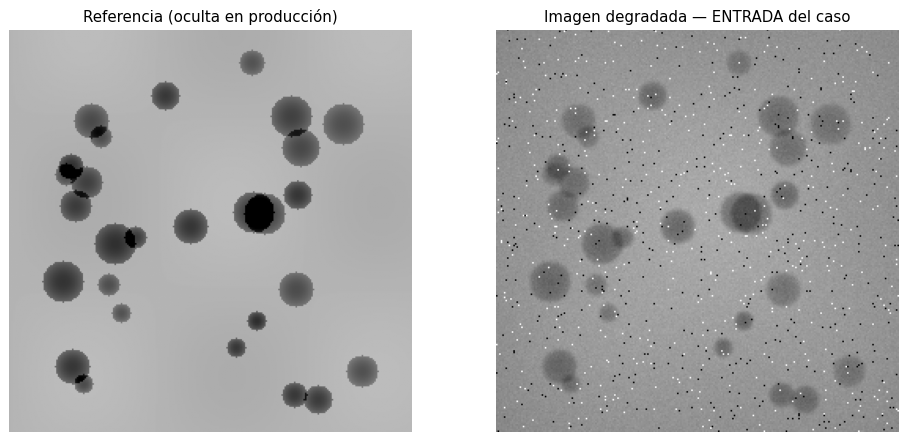

In [4]:
# Generación determinista del caso - NO MODIFICAR
# Esta celda construye una micrografía sintética y su versión degradada.

def _generar_micrografia(size=256, seed=2026):
    rng = np.random.RandomState(seed)
    H = W = size

    # Fondo (citoplasma) con textura suave de baja frecuencia
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float64)
    fondo = 180 + 8 * np.sin(xx / 30.0) * np.cos(yy / 35.0)

    # Núcleos celulares: discos oscuros distribuidos
    nucleos = np.zeros((H, W), dtype=np.float64)
    n_celulas = 28
    for _ in range(n_celulas):
        cy = rng.randint(20, H - 20)
        cx = rng.randint(20, W - 20)
        r = rng.randint(6, 14)
        intens = rng.uniform(45, 85)  # núcleos oscuros
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
        # Perfil suave del núcleo
        d = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
        perfil = np.where(mask, (intens - fondo) * (1 - (d / r) ** 2 * 0.4), 0)
        nucleos += perfil

    limpia = np.clip(fondo + nucleos, 0, 255)
    return limpia.astype(np.float64)


def _degradar(img, seed=2026):
    rng = np.random.RandomState(seed + 1)
    H, W = img.shape

    # (1) Iluminación no uniforme: máscara radial gaussiana centrada
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float64)
    cy, cx = H / 2, W / 2
    sigma_il = H * 0.45
    iluminacion = 0.55 + 0.55 * np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma_il ** 2))
    out = img * iluminacion

    # (2) Reducción de contraste global (mapeo lineal hacia el centro)
    out = 80 + (out - out.min()) * (170 - 80) / (out.max() - out.min() + 1e-9)

    # (3) Pérdida de nitidez: pequeño desenfoque gaussiano
    k = np.array([[1, 4, 6, 4, 1],
                  [4, 16, 24, 16, 4],
                  [6, 24, 36, 24, 6],
                  [4, 16, 24, 16, 4],
                  [1, 4, 6, 4, 1]], dtype=np.float64) / 256.0
    out = convolve2d(out, k, mode='same', boundary='symm')

    # (4) Ruido gaussiano de baja varianza
    out = out + rng.normal(0, 4.0, out.shape)

    # (5) Ruido sal y pimienta (componente impulsivo)
    p = 0.015
    mascara = rng.rand(H, W)
    out = np.where(mascara < p / 2, 0, out)
    out = np.where(mascara > 1 - p / 2, 255, out)

    return np.clip(out, 0, 255).astype(np.float64)


I_clean = _generar_micrografia()
I_deg = _degradar(I_clean)

print(f"Imagen original (referencia oculta): {I_clean.shape}, rango [{I_clean.min():.1f}, {I_clean.max():.1f}]")
print(f"Imagen degradada (entrada del caso): {I_deg.shape}, rango [{I_deg.min():.1f}, {I_deg.max():.1f}]")

# Visualización inicial
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(I_clean, vmin=0, vmax=255); axes[0].set_title('Referencia (oculta en producción)'); axes[0].axis('off')
axes[1].imshow(I_deg, vmin=0, vmax=255); axes[1].set_title('Imagen degradada — ENTRADA del caso'); axes[1].axis('off')
plt.tight_layout(); plt.show()


---

## Sección 1 — Diagnóstico y exploración (3 puntos)

Realice una exploración de la imagen degradada `I_deg`. Como mínimo:

1. Estadísticos globales: media, desviación estándar, mínimo, máximo.
2. Histograma de intensidades de `I_deg`.
3. Visualización ampliada de una pequeña región (por ejemplo, un recorte de 40×40 píxeles) para identificar a simple vista el ruido impulsivo.
4. Comentario breve sobre la distribución del brillo: ¿es más claro el centro que las orillas? Apóyese visualmente en la imagen.


Estadísticos de I_deg:
  media   = 147.61
  std     = 21.65
  min/max = 0.0 / 255.0


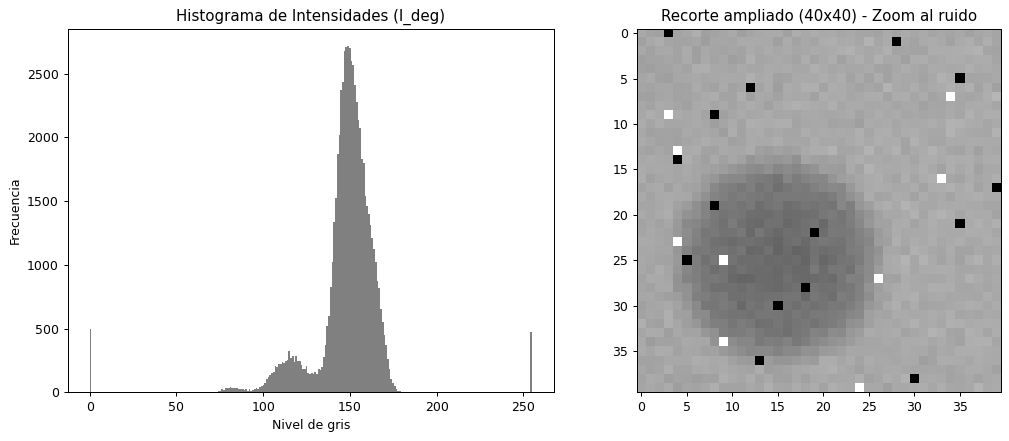

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Estadísticos globales
mean_val = np.mean(I_deg)
std_val = np.std(I_deg)
min_val = np.min(I_deg)
max_val = np.max(I_deg)

print("Estadísticos de I_deg:")
print(f"  media   = {mean_val:.2f}")
print(f"  std     = {std_val:.2f}")
print(f"  min/max = {min_val:.1f} / {max_val:.1f}")

# 2. Histograma y 3. Recorte ampliado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
ax[0].hist(I_deg.ravel(), bins=256, color='gray', range=[0, 255])
ax[0].set_title('Histograma de Intensidades (I_deg)')
ax[0].set_xlabel('Nivel de gris')
ax[0].set_ylabel('Frecuencia')

# Recorte de 40x40 (en el centro para ver ruido y núcleos)
recorte = I_deg[100:140, 100:140]
ax[1].imshow(recorte, vmin=0, vmax=255)
ax[1].set_title('Recorte ampliado (40x40) - Zoom al ruido')
ax[1].axis('on') # Mostramos ejes para confirmar dimensiones

plt.tight_layout()
plt.show()

### Diagnóstico — interpretación

1. **Ruido Impulsivo (Sal y Pimienta):** Es la degradación más severa visualmente, evidenciada por los valores mínimos (0) y máximos (255) y los puntos aislados en el recorte.
2. **Iluminación No Uniforme:** El histograma centrado cerca de 150 y la observación visual confirman que el centro es más brillante que las orillas (efecto de degradado radial).
3. **Bajo Contraste:** La baja desviación estándar (21.65) indica que la mayoría de los píxeles están agrupados en un rango estrecho, dificultando la distinción entre núcleos y fondo.
4. **Pérdida de Nitidez:** Los bordes de los núcleos en el recorte se ven difusos (mancha borrosa), lo que requiere un filtrado de realce tras limpiar el ruido.

**Orden de resolución:** Primero suprimiré el ruido impulsivo (filtro de mediana), luego corregiré la iluminación/contraste y finalmente aplicaré un realce de bordes.

## Sección 2 — Plan de procesamiento y justificación (3 puntos)

| Etapa | Operación elegida | Parámetros | Razón de elección | Razón de la posición en el pipeline |
|-------|-------------------|------------|-------------------|--------------------------------------|
| 1     | Filtro de Mediana | Kernel $3 \times 3$ | Según el libro, es la herramienta óptima para suprimir ruido impulsivo (sal y pimienta) preservando bordes. | Se coloca primero para eliminar los outliers (0 y 255) antes de que afecten cálculos de promedios o gradientes. |
| 2     | Unsharp Masking / High-boost | $\sigma=1.0, k=1.5$ | Técnica clásica del libro para compensar el desenfoque mediante la suma de la imagen y su máscara difusa. | Se aplica tras limpiar el ruido para no amplificar los puntos de sal y pimienta no deseados. |
| 3     | Estiramiento de Contraste (Lineal) | Percentiles 1-99 | Mejora el rango dinámico y compensa parcialmente el vigneteado al normalizar intensidades. | Se realiza al final para ajustar la estética visual y el histograma del resultado ya restaurado en nitidez y ruido. |

---

## Sección 3 — Implementación (5 puntos)

Implemente el pipeline diseñado. Use **una celda de código por etapa**, con un comentario inicial breve indicando qué hace. Muestre la imagen al final de cada etapa para verificar el efecto.

**Buenas prácticas exigidas:**

- Mantenga `I_deg` intacta (trabaje sobre copias).
- Maneje los tipos de dato cuidadosamente: trabaje en `float64` durante el procesamiento y solo cuantice a `uint8` al final si lo desea.
- Si usa parámetros (tamaño de kernel, $\sigma$, etc.), declárelos como variables con nombre al inicio de la celda, no como números mágicos enterrados en la llamada.


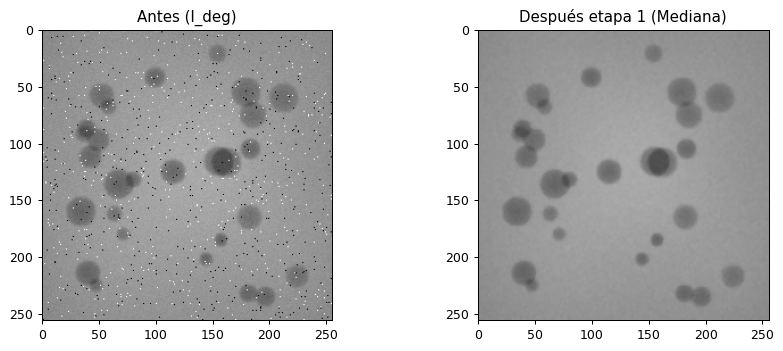

In [11]:
# Etapa 1 — Filtro de Mediana
# Justificacion: Se utiliza para eliminar el ruido impulsivo (puntos blancos y negros)
# preservando los bordes de los nucleos antes de aplicar realces.

size_kernel = 3
I_etapa1 = ndimage.median_filter(I_deg, size=size_kernel)

# Visualizar
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(I_deg, vmin=0, vmax=255); ax[0].set_title('Antes (I_deg)')
ax[1].imshow(I_etapa1, vmin=0, vmax=255); ax[1].set_title('Después etapa 1 (Mediana)')
plt.tight_layout(); plt.show()

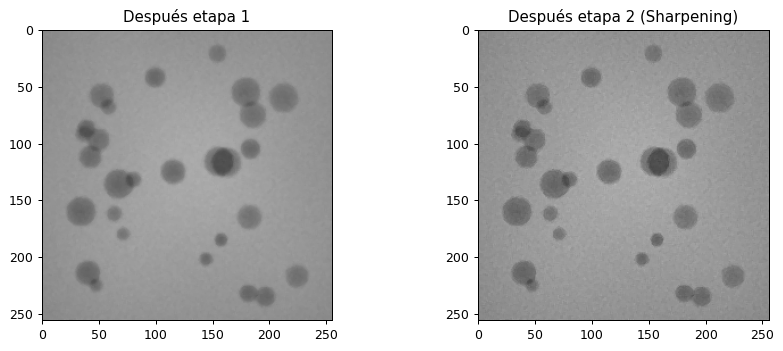

In [13]:
# Etapa 2 — Unsharp Masking (High-boost)
# Justificacion: Compensamos el desenfoque original restando una versión suavizada
# de la imagen para resaltar los detalles de los bordes.

sigma_blur = 1.0
k_strength = 1.5

# Generar la version suavizada
I_blur = ndimage.gaussian_filter(I_etapa1, sigma=sigma_blur)

# Aplicar la mascara: I_sharp = I + k * (I - I_blur)
I_etapa2 = I_etapa1 + k_strength * (I_etapa1 - I_blur)
I_etapa2 = np.clip(I_etapa2, 0, 255)

# Visualizar
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(I_etapa1, vmin=0, vmax=255); ax[0].set_title('Después etapa 1')
ax[1].imshow(I_etapa2, vmin=0, vmax=255); ax[1].set_title('Después etapa 2 (Sharpening)')
plt.tight_layout(); plt.show()

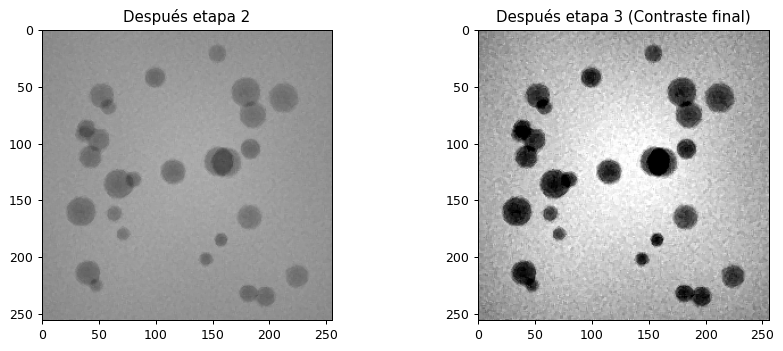

In [14]:
# Etapa 3 — Estiramiento de Contraste Lineal
# Justificacion: Normalizamos el rango dinamico basandonos en percentiles para
# mejorar la visibilidad de los nucleos y mitigar el efecto de la iluminacion no uniforme.

p_min, p_max = np.percentile(I_etapa2, (1, 99))

# Mapeo lineal: (I - p_min) / (p_max - p_min) * 255
I_etapa3 = np.clip((I_etapa2 - p_min) / (p_max - p_min) * 255, 0, 255)

# Visualizar
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(I_etapa2, vmin=0, vmax=255); ax[0].set_title('Después etapa 2')
ax[1].imshow(I_etapa3, vmin=0, vmax=255); ax[1].set_title('Después etapa 3 (Contraste final)')
plt.tight_layout(); plt.show()

In [15]:
# Asignación final
I_restaurada = I_etapa3.copy()

---

## Sección 4 — Evaluación cuantitativa y comparación (2 puntos)

Compare cuantitativa y visualmente `I_restaurada` con la referencia `I_clean`:

1. **RMSE** (error cuadr&aacute;tico medio) entre `I_deg` y `I_clean`, y entre `I_restaurada` y `I_clean`. Comente si su pipeline mejoró el resultado.
2. **Histograma comparativo** de las tres imágenes (`I_clean`, `I_deg`, `I_restaurada`) en un solo gráfico.
3. **Triple panel visual**: las tres imágenes lado a lado.


Comparación cuantitativa (RMSE)
--------------------------------
RMSE (degradada  vs clean) = 34.949
RMSE (restaurada vs clean) = 30.279


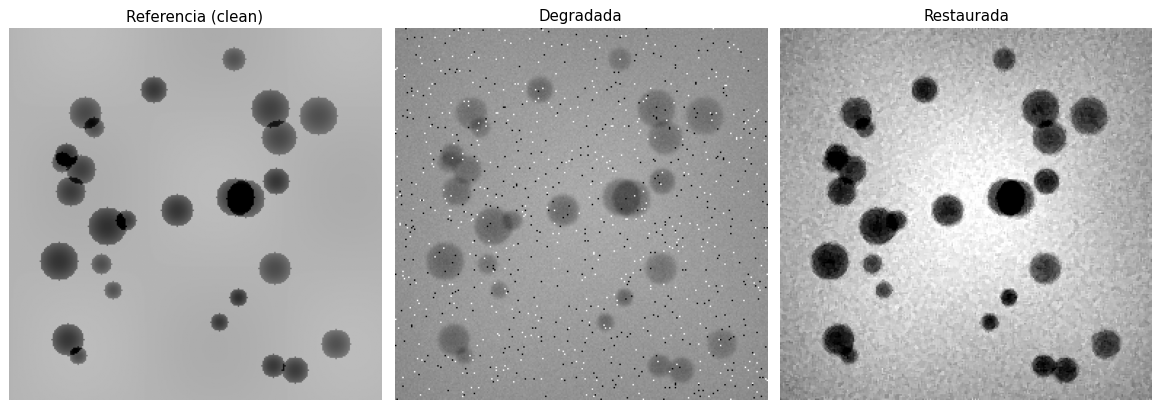

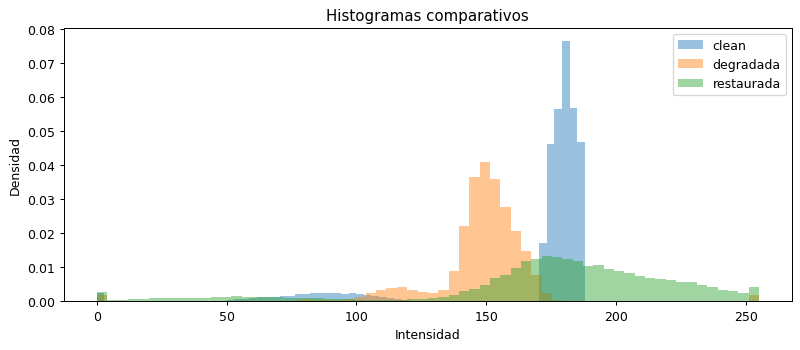

In [16]:
# Sección 4 - Evaluación cuantitativa
def rmse(a, b):
    return float(np.sqrt(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)))

print("Comparación cuantitativa (RMSE)")
print("--------------------------------")
print(f"RMSE (degradada  vs clean) = {rmse(I_deg, I_clean):.3f}")
print(f"RMSE (restaurada vs clean) = {rmse(I_restaurada, I_clean):.3f}")

# Triple panel visual
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(I_clean, vmin=0, vmax=255); axes[0].set_title('Referencia (clean)'); axes[0].axis('off')
axes[1].imshow(I_deg, vmin=0, vmax=255); axes[1].set_title('Degradada'); axes[1].axis('off')
axes[2].imshow(I_restaurada, vmin=0, vmax=255); axes[2].set_title('Restaurada'); axes[2].axis('off')
plt.tight_layout(); plt.show()

# Histogramas comparativos
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(I_clean.ravel(), bins=64, alpha=0.45, label='clean', density=True)
ax.hist(I_deg.ravel(), bins=64, alpha=0.45, label='degradada', density=True)
ax.hist(I_restaurada.ravel(), bins=64, alpha=0.45, label='restaurada', density=True)
ax.legend(); ax.set_xlabel('Intensidad'); ax.set_ylabel('Densidad')
ax.set_title('Histogramas comparativos')
plt.tight_layout(); plt.show()


---

## Sección 5 — Discusión (1 punto)

Responda en celda Markdown, en 4 a 6 líneas en total:

1. ¿Qué problema de la imagen quedó mejor resuelto y cuál peor?
2. Si tuviera que mejorar su pipeline, ¿qué etapa cambiaría o agregaría, y por qué?


### Respuesta — Discusión

**1.** El problema mejor resuelto fue el ruido impulsivo, ya que el filtro de mediana logro eliminar por completo los puntos de sal y pimienta sin difuminar excesivamente los nucleos.

El que quedo peor resuelto fue la iluminacion no uniforme. Aunque el estiramiento de contraste mejoro la visibilidad, el histograma muestra que la distribucion de la imagen restaurada aun difiere de la referencia, manteniendo las periferias ligeramente mas oscuras que el centro.

**2.** Para mejorar el pipeline, agregaría una etapa de división por fondo estimado al inicio.

En lugar de un estiramiento global, estimar el perfil de iluminacion con un filtro de paso bajo (quisaz un Filtro Gaussiano) y dividir la imagen degradada por este perfil permitiria corregir el vigneteado de forma local, logrando un fondo mucho mas homogéneo antes de realzar la nitidez.

# Declaración uso de IA

Para el desarrollo del presente examen, use la Inteligencia Artifical para poder comparar respuestas de analisis, mas que todo para saber si lo que yo pensaba estaba bien o habían otros métodos mejores para el procesamiento.